# Giai đoạn 2 — Phân tích dữ liệu và Feature Engineering
## Đề tài: Dự đoán khách hàng rời bỏ ứng dụng mua bán online của công ty TAD

## Phần 1 — Import thư viện và đọc dữ liệu

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.feature_selection import mutual_info_classif
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
import pickle
import os
import warnings

warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 100
sns.set_style('whitegrid')

os.makedirs('data', exist_ok=True)
os.makedirs('models', exist_ok=True)

print('Import xong.')

Import xong.


In [2]:
df = pd.read_csv(r'/Users/thanhnhat/Documents/mock project/Data/churn_data_customer.csv')
print('Số dòng:', len(df))
print('Số cột:', df.shape[1])
print()
print('Danh sách cột:')
print(df.columns.tolist())

Số dòng: 50000
Số cột: 24

Danh sách cột:
['customer_id', 'age', 'account_tenure_months', 'monthly_active_days', 'avg_daily_usage_minutes', 'num_sessions_per_week', 'support_tickets_30d', 'payment_delay_days', 'subscription_type', 'has_active_promo', 'app_rating', 'num_notification_opt_out', 'customer_support_satisfaction', 'monthly_charges', 'churn_target', 'avg_active_days_3m', 'usage_minutes_3m', 'support_tickets_3m', 'avg_active_days_6m', 'usage_minutes_6m', 'support_tickets_6m', 'avg_active_days_12m', 'usage_minutes_12m', 'support_tickets_12m']


## Phần 2 — Khám phá tổng quan dữ liệu (EDA)

EDA là bước làm quen với dữ liệu trước khi xử lý bất cứ thứ gì. Kiểm tra: cấu trúc, giá trị thiếu, trùng lặp, phân phối từng biến, và giá trị bất thường (outlier).

### 2.1 Cấu trúc dữ liệu

In [3]:
df.head()

,customer_id,age,account_tenure_months,monthly_active_days,avg_daily_usage_minutes,num_sessions_per_week,support_tickets_30d,payment_delay_days,subscription_type,has_active_promo,...,churn_target,avg_active_days_3m,usage_minutes_3m,support_tickets_3m,avg_active_days_6m,usage_minutes_6m,support_tickets_6m,avg_active_days_12m,usage_minutes_12m,support_tickets_12m
0,1,47,13,20,56.015159,11,1,1,Basic,Yes,...,0,19.961873,55.132001,3,23.172775,78.450835,6,19.475123,81.148526,12
1,2,37,34,1,9.461102,1,0,4,Premium,No,...,0,3.414577,24.497152,0,0.000000,11.011013,0,0.378232,0.000000,0
2,3,50,5,26,157.328391,13,0,0,Basic,No,...,0,27.250585,141.228249,0,26.000000,157.328391,0,26.000000,157.328391,0
3,4,65,46,23,79.827399,10,1,0,Premium,Yes,...,0,21.390622,81.776686,3,25.724136,102.048156,6,22.959400,26.707923,12
4,5,37,2,20,50.339759,10,0,3,Premium,No,...,1,13.333333,33.559839,0,20.000000,50.339759,0,20.000000,50.339759,0


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 24 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   customer_id                    50000 non-null  int64  
 1   age                            50000 non-null  int64  
 2   account_tenure_months          50000 non-null  int64  
 3   monthly_active_days            50000 non-null  int64  
 4   avg_daily_usage_minutes        50000 non-null  float64
 5   num_sessions_per_week          50000 non-null  int64  
 6   support_tickets_30d            50000 non-null  int64  
 7   payment_delay_days             50000 non-null  int64  
 8   subscription_type              50000 non-null  str    
 9   has_active_promo               50000 non-null  str    
 10  app_rating                     50000 non-null  int64  
 11  num_notification_opt_out       50000 non-null  int64  
 12  customer_support_satisfaction  50000 non-null  int64  
 1

In [5]:
df.describe().round(2)

,customer_id,age,account_tenure_months,monthly_active_days,avg_daily_usage_minutes,num_sessions_per_week,support_tickets_30d,payment_delay_days,app_rating,num_notification_opt_out,...,churn_target,avg_active_days_3m,usage_minutes_3m,support_tickets_3m,avg_active_days_6m,usage_minutes_6m,support_tickets_6m,avg_active_days_12m,usage_minutes_12m,support_tickets_12m
count,50000.00,50000.00,50000.0,50000.0,50000.00,50000.00,50000.00,50000.00,50000.00,50000.00,...,50000.00,50000.00,50000.00,50000.00,50000.00,50000.00,50000.00,50000.00,50000.00,50000.00
mean,25000.50,39.90,29.3,19.1,60.39,8.48,0.82,3.21,3.85,1.50,...,0.24,18.03,57.09,2.25,19.10,60.64,4.09,19.10,60.52,6.73
std,14433.90,13.79,27.9,7.2,28.81,3.35,1.60,6.00,1.20,1.24,...,0.43,7.86,30.81,4.60,7.36,31.37,8.88,7.33,32.57,16.41
min,1.00,18.00,1.0,1.0,5.00,1.00,0.00,0.00,1.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,12500.75,29.00,8.0,16.0,47.21,7.00,0.00,0.00,3.00,1.00,...,0.00,13.60,37.83,0.00,15.87,43.14,0.00,16.00,41.85,0.00
50%,25000.50,40.00,21.0,21.0,62.71,9.00,0.00,1.00,4.00,1.00,...,0.00,19.80,58.89,0.00,20.78,61.91,0.00,20.85,61.65,0.00
75%,37500.25,50.00,41.0,24.0,74.86,11.00,1.00,3.00,5.00,2.00,...,0.00,24.03,74.94,3.00,24.35,77.48,6.00,24.32,77.92,12.00
max,50000.00,70.00,120.0,30.0,480.00,16.00,9.00,30.00,5.00,9.00,...,1.00,30.00,471.22,27.00,30.00,480.00,54.00,30.00,480.00,108.00


### 2.2 Kiểm tra giá trị thiếu và dòng trùng lặp

In [6]:
missing = df.isnull().sum()
if missing.sum() == 0:
    print('Không có giá trị bị thiếu. Dữ liệu sạch từ Giai đoạn 1.')
else:
    print('Các cột bị thiếu:')
    print(missing[missing > 0])

dup = df.duplicated().sum()
print('Số dòng trùng lặp:', dup)
if dup == 0:
    print('Không có dòng nào bị trùng lặp.')

Không có giá trị bị thiếu. Dữ liệu sạch từ Giai đoạn 1.
Số dòng trùng lặp: 0
Không có dòng nào bị trùng lặp.


### 2.3 Phân phối các biến số chính

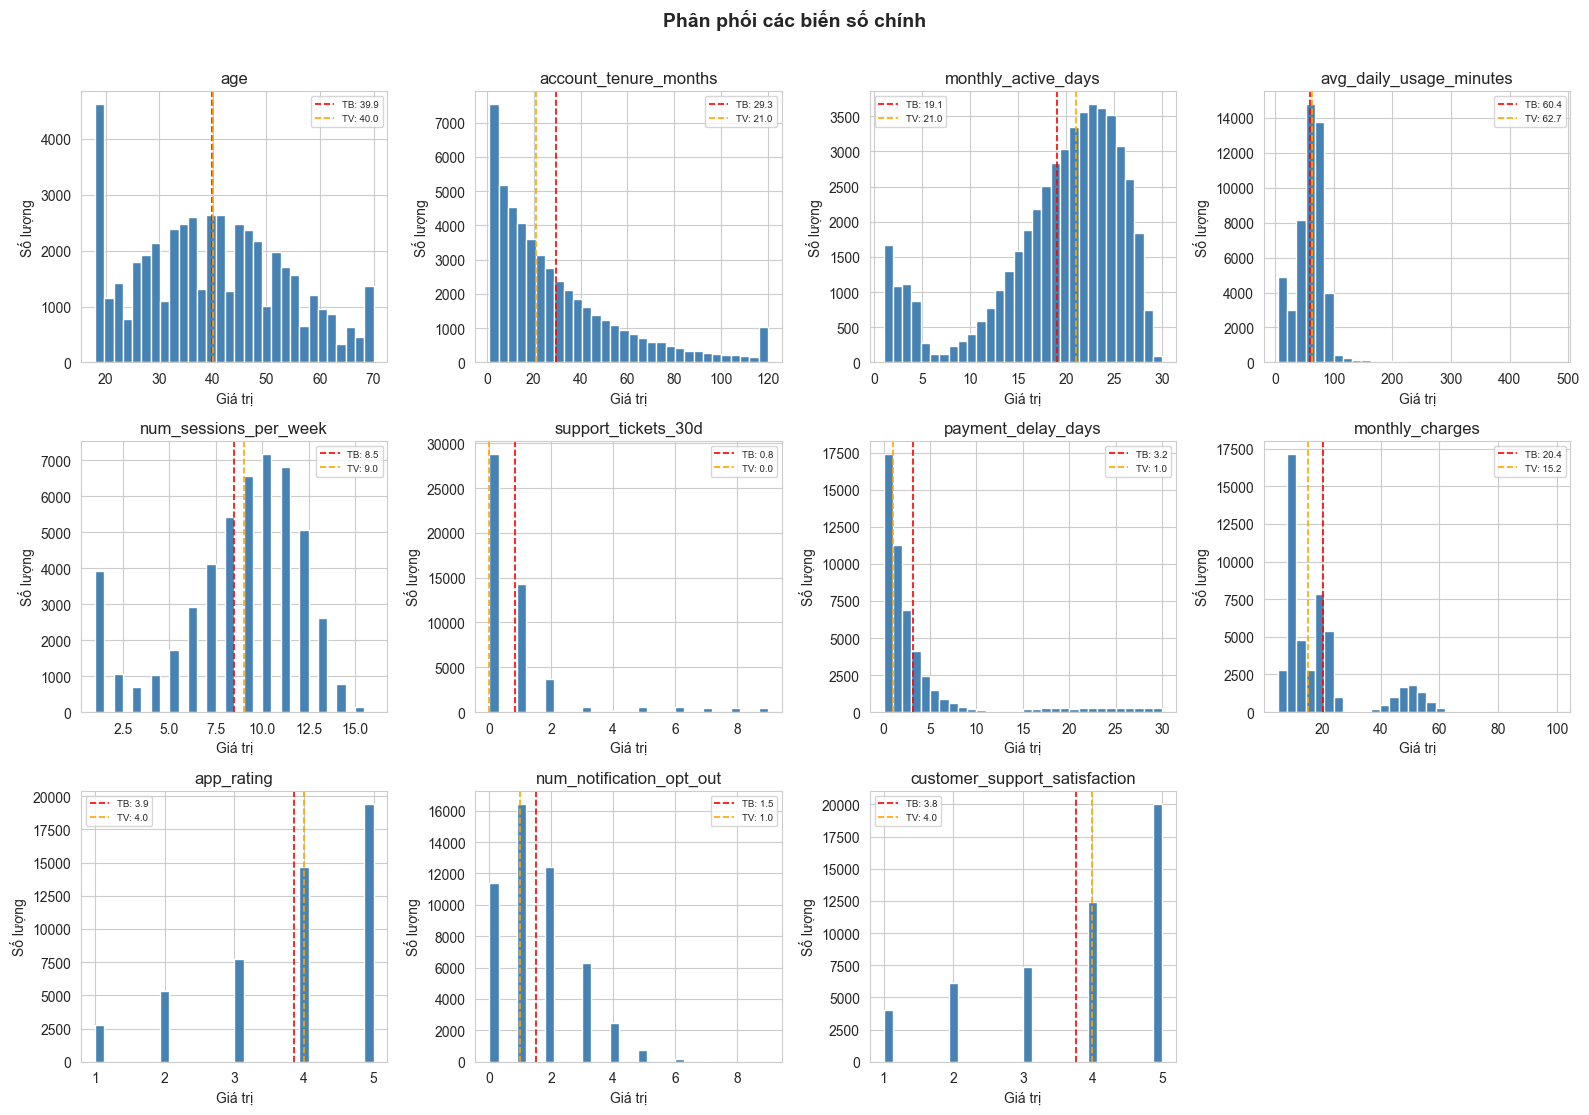

In [7]:
cols_plot = [
    'age', 'account_tenure_months', 'monthly_active_days',
    'avg_daily_usage_minutes', 'num_sessions_per_week',
    'support_tickets_30d', 'payment_delay_days', 'monthly_charges',
    'app_rating', 'num_notification_opt_out', 'customer_support_satisfaction'
]

fig, axes = plt.subplots(3, 4, figsize=(16, 11))
axes = axes.flatten()

for i, col in enumerate(cols_plot):
    axes[i].hist(df[col], bins=30, color='steelblue', edgecolor='white')
    axes[i].axvline(df[col].mean(), color='red', linestyle='--', linewidth=1.2,
                    label='TB: ' + str(round(df[col].mean(), 1)))
    axes[i].axvline(df[col].median(), color='orange', linestyle='--', linewidth=1.2,
                    label='TV: ' + str(round(df[col].median(), 1)))
    axes[i].set_title(col)
    axes[i].set_xlabel('Giá trị')
    axes[i].set_ylabel('Số lượng')
    axes[i].legend(fontsize=7)

for j in range(len(cols_plot), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Phân phối các biến số chính', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('data/01_phan_phoi_bien_so.png', bbox_inches='tight')
plt.show()

**Nhận xét:**
- **age**: phân phối tương đối đều, khách hàng TAD chủ yếu ở độ tuổi 18–70.
- **account_tenure_months**: lệch phải, nhiều khách hàng mới dùng dưới 20 tháng.
- **monthly_active_days**: tập trung 16–25 ngày, phân phối khá đối xứng.
- **avg_daily_usage_minutes**: lệch phải, đa số dùng 40–80 phút/ngày. Một số nhỏ dùng rất nhiều (480 phút) — có thể là tiểu thương hoạt động thường xuyên.
- **num_sessions_per_week**: tập trung 6–11 phiên/tuần, phân phối khá đều.
- **support_tickets_30d**: phân phối Poisson, đa số không tạo ticket nào (giá trị 0 phổ biến).
- **payment_delay_days**: nhiều khách thanh toán đúng hạn, một số ít trễ nhiều ngày.
- **monthly_charges**: lệch phải, đa số ở mức phí thấp (gói Basic), một số ở mức cao (VIP).
- **app_rating** và **customer_support_satisfaction**: tập trung ở 3–5, khá hài lòng.

### 2.4 Phân phối các biến danh mục

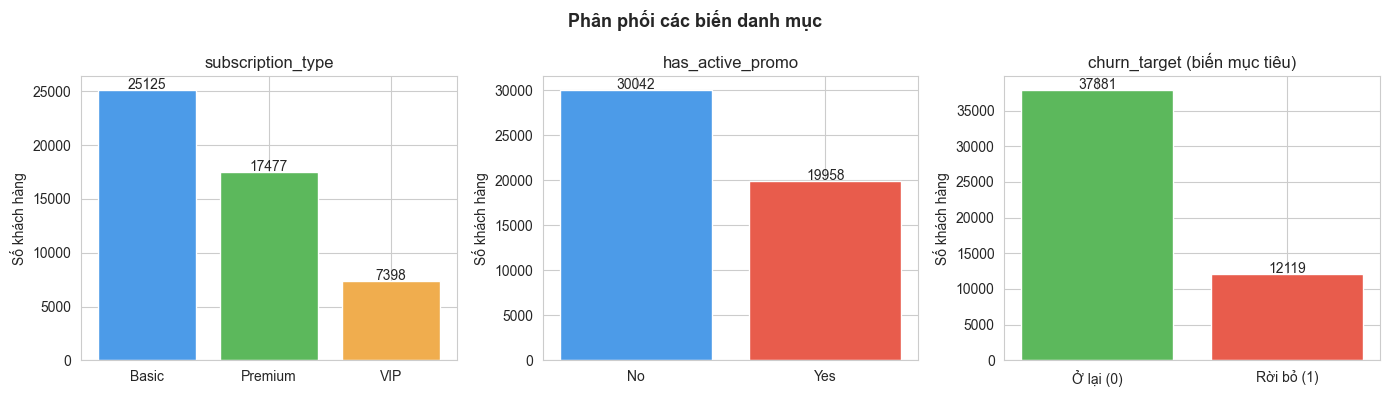

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

sub_counts = df['subscription_type'].value_counts()
axes[0].bar(sub_counts.index, sub_counts.values, color=['#4C9BE8', '#5CB85C', '#F0AD4E'])
axes[0].set_title('subscription_type')
axes[0].set_ylabel('Số khách hàng')
for i, v in enumerate(sub_counts.values):
    axes[0].text(i, v + 100, str(v), ha='center')

promo_counts = df['has_active_promo'].value_counts()
axes[1].bar(promo_counts.index, promo_counts.values, color=['#4C9BE8', '#E85C4C'])
axes[1].set_title('has_active_promo')
axes[1].set_ylabel('Số khách hàng')
for i, v in enumerate(promo_counts.values):
    axes[1].text(i, v + 100, str(v), ha='center')

churn_counts = df['churn_target'].value_counts()
axes[2].bar(['Ở lại (0)', 'Rời bỏ (1)'], churn_counts.values, color=['#5CB85C', '#E85C4C'])
axes[2].set_title('churn_target (biến mục tiêu)')
axes[2].set_ylabel('Số khách hàng')
for i, v in enumerate(churn_counts.values):
    axes[2].text(i, v + 100, str(v), ha='center')

plt.suptitle('Phân phối các biến danh mục', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('data/02_phan_phoi_bien_danh_muc.png', bbox_inches='tight')
plt.show()

pct_churn = churn_counts[1] / len(df) * 100
pct_stay = churn_counts[0] / len(df) * 100

**Nhận xét:**
- **subscription_type**: gói Basic chiếm nhiều nhất (~50%), tiếp theo là Premium và VIP.
- **has_active_promo**: khoảng 60% khách hàng không có khuyến mãi, 40% đang có.
- **churn_target**: tỉ lệ khách rời bỏ ở mức hợp lý, dữ liệu không bị mất cân bằng quá nghiêm trọng.

### 2.5 Kiểm tra outlier (giá trị bất thường)

In [9]:
cols_check = [
    'age', 'account_tenure_months', 'monthly_active_days',
    'avg_daily_usage_minutes', 'payment_delay_days', 'monthly_charges'
]

print('{:<30} {:>8} {:>8} {:>10} {:>8}'.format('Cột', 'Q1', 'Q3', 'Outlier', 'Tỉ lệ'))
print('-' * 68)

for col in cols_check:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    n_out = ((df[col] < q1 - 1.5 * iqr) | (df[col] > q3 + 1.5 * iqr)).sum()
    print('{:<30} {:>8.1f} {:>8.1f} {:>10,} {:>7.1f}%'.format(col, q1, q3, n_out, n_out/len(df)*100))

Cột                                  Q1       Q3    Outlier    Tỉ lệ
--------------------------------------------------------------------
age                                29.0     50.0          0     0.0%
account_tenure_months               8.0     41.0      2,488     5.0%
monthly_active_days                16.0     24.0      3,863     7.7%
avg_daily_usage_minutes            47.2     74.9      3,124     6.2%
payment_delay_days                  0.0      3.0      4,863     9.7%
monthly_charges                    10.0     21.8      7,991    16.0%


**Nhận xét:**
- **avg_daily_usage_minutes** có nhiều outlier (một số tiểu thương dùng app rất nhiều giờ).
- **monthly_charges** có outlier do chênh lệch giá giữa gói Basic và VIP — đây là thực tế kinh doanh.
- **payment_delay_days**: một số khách trễ thanh toán rất nhiều ngày.
- Các outlier này đều có thể giải thích được nên không cần loại bỏ. Mô hình RandomForest và XGBoost dùng ở Giai đoạn 3 khá bền vững với outlier.

### 2.6 Phân phối các biến derived timeframe (3 tháng / 6 tháng / 12 tháng)

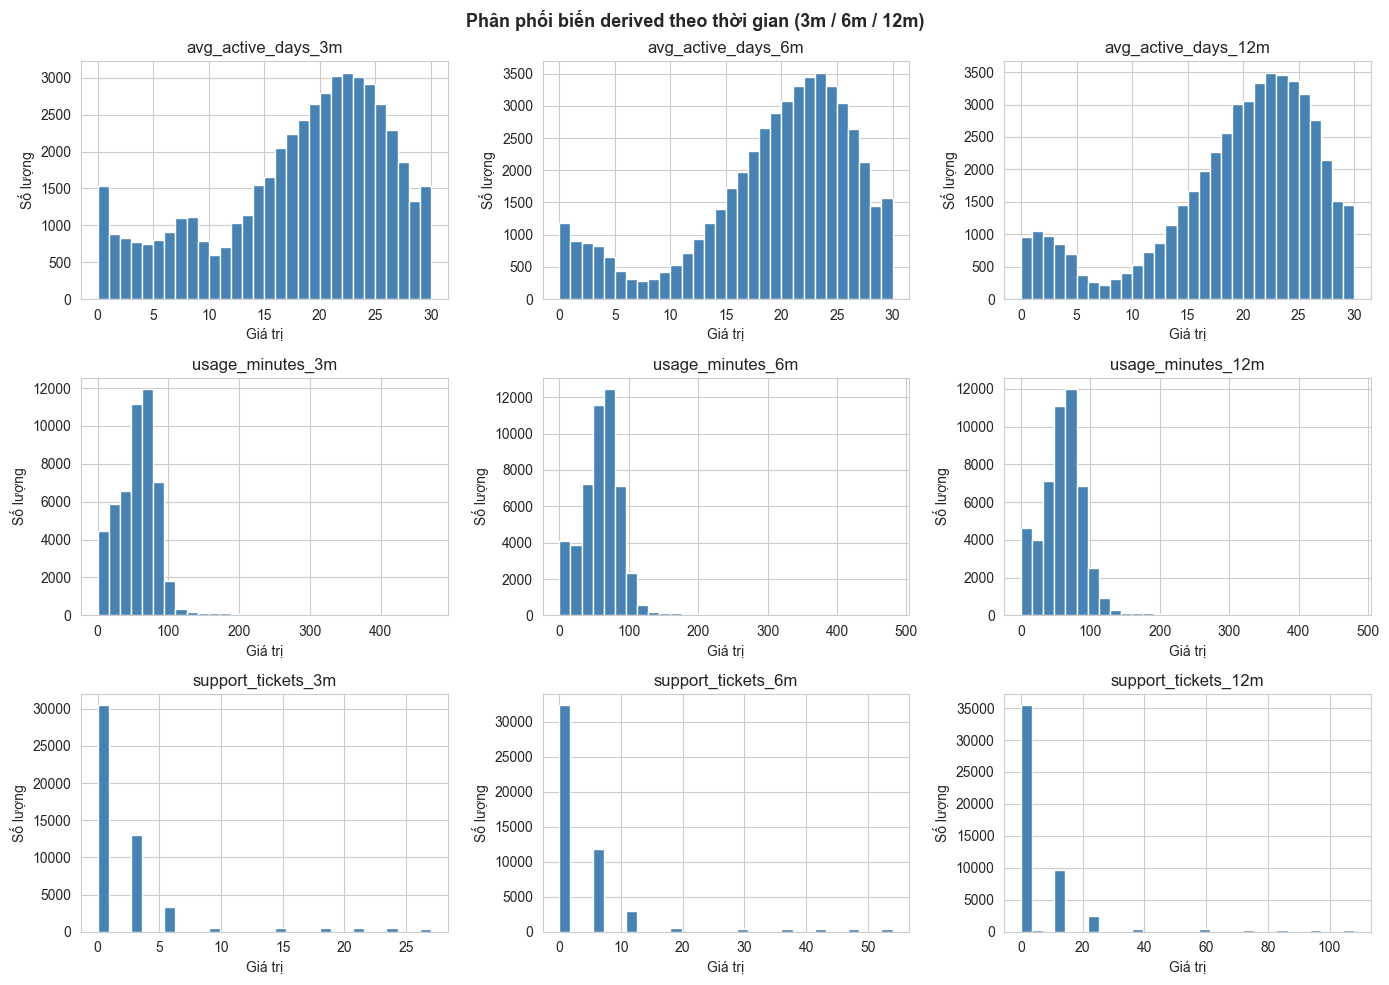

In [10]:
groups = [
    ('avg_active_days', ['avg_active_days_3m', 'avg_active_days_6m', 'avg_active_days_12m']),
    ('usage_minutes',   ['usage_minutes_3m', 'usage_minutes_6m', 'usage_minutes_12m']),
    ('support_tickets', ['support_tickets_3m', 'support_tickets_6m', 'support_tickets_12m']),
]

fig, axes = plt.subplots(3, 3, figsize=(14, 10))

for row_i, (gname, cols) in enumerate(groups):
    for col_i, col in enumerate(cols):
        axes[row_i][col_i].hist(df[col], bins=30, color='steelblue', edgecolor='white')
        axes[row_i][col_i].set_title(col)
        axes[row_i][col_i].set_xlabel('Giá trị')
        axes[row_i][col_i].set_ylabel('Số lượng')

plt.suptitle('Phân phối biến derived theo thời gian (3m / 6m / 12m)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('data/03_phan_phoi_bien_timeframe.png', bbox_inches='tight')
plt.show()

**Nhận xét:**
- **avg_active_days_3m/6m/12m**: phân phối tương tự nhau và ổn định qua thời gian.
- **usage_minutes_3m/6m/12m**: lệch phải, tương tự avg_daily_usage_minutes.
- **support_tickets_3m/6m/12m**: lệch phải mạnh, nhiều khách không có ticket. Giá trị tăng dần từ 3m đến 12m vì tính lũy tích theo thời gian.
- Các biến trong cùng nhóm tương quan cao với nhau → sẽ xử lý ở bước chọn biến.

## Phần 3 — Mối quan hệ giữa các biến với churn_target

Sau khi hiểu từng biến riêng lẻ, phân tích xem biến nào liên quan đến việc khách hàng rời bỏ app TAD.

### 3.1 Tương quan của các biến số với churn_target

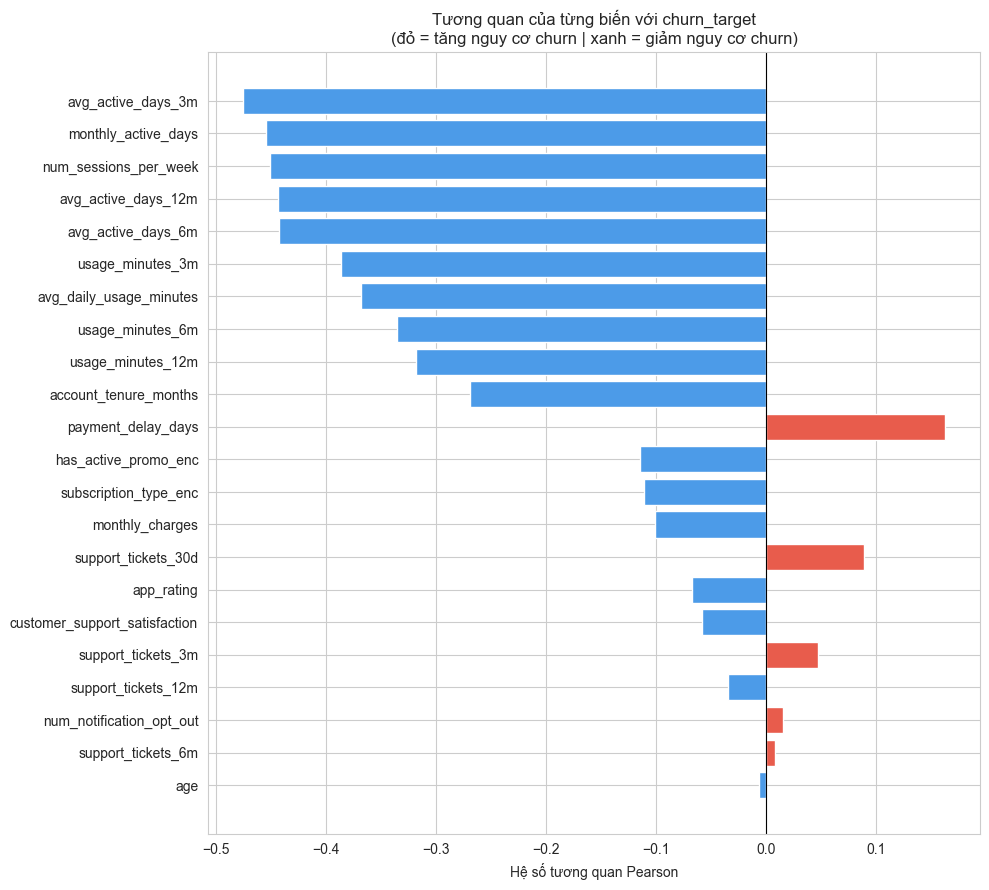

Top 10 biến tương quan mạnh nhất với churn:
avg_active_days_3m        -0.4755
monthly_active_days       -0.4542
num_sessions_per_week     -0.4510
avg_active_days_12m       -0.4439
avg_active_days_6m        -0.4425
usage_minutes_3m          -0.3860
avg_daily_usage_minutes   -0.3685
usage_minutes_6m          -0.3355
usage_minutes_12m         -0.3185
account_tenure_months     -0.2692


In [11]:
df_enc = df.copy()
df_enc['subscription_type_enc'] = LabelEncoder().fit_transform(df_enc['subscription_type'])
df_enc['has_active_promo_enc'] = (df_enc['has_active_promo'] == 'Yes').astype(int)

num_cols_all = [c for c in df_enc.select_dtypes(include=np.number).columns
                if c not in ['customer_id', 'churn_target']]

corr = df_enc[num_cols_all + ['churn_target']].corr()['churn_target'].drop('churn_target')
corr_sorted = corr.reindex(corr.abs().sort_values(ascending=False).index)

plt.figure(figsize=(10, 9))
colors = ['#E85C4C' if v > 0 else '#4C9BE8' for v in corr_sorted.values]
plt.barh(corr_sorted.index[::-1], corr_sorted.values[::-1], color=colors[::-1])
plt.axvline(0, color='black', linewidth=0.8)
plt.xlabel('Hệ số tương quan Pearson')
plt.title('Tương quan của từng biến với churn_target\n(đỏ = tăng nguy cơ churn | xanh = giảm nguy cơ churn)')
plt.tight_layout()
plt.savefig('data/04_tuong_quan_voi_churn.png', bbox_inches='tight')
plt.show()

print('Top 10 biến tương quan mạnh nhất với churn:')
print(corr_sorted.head(10).round(4).to_string())

**Nhận xét:**
- **avg_active_days_3m** (−0.48): số ngày hoạt động 3 tháng gần nhất là biến tương quan mạnh nhất với churn. Khách hàng ít hoạt động trong thời gian gần đây rất dễ rời bỏ.
- **monthly_active_days** (−0.45) và **num_sessions_per_week** (−0.45): hành vi sử dụng tháng hiện tại cũng rất quan trọng. Cả 3 biến này đều đo "mức độ tương tác" với app.
- **avg_daily_usage_minutes** (−0.37) và **usage_minutes_3m** (−0.39): thời gian dùng ít → dễ churn.
- **payment_delay_days** (+0.16): trễ thanh toán nhiều → nguy cơ churn tăng.
- **account_tenure_months** (−0.27): khách dùng lâu ít churn hơn (đã gắn bó với dịch vụ).

### 3.2 So sánh phân phối biến số giữa nhóm rời bỏ và ở lại

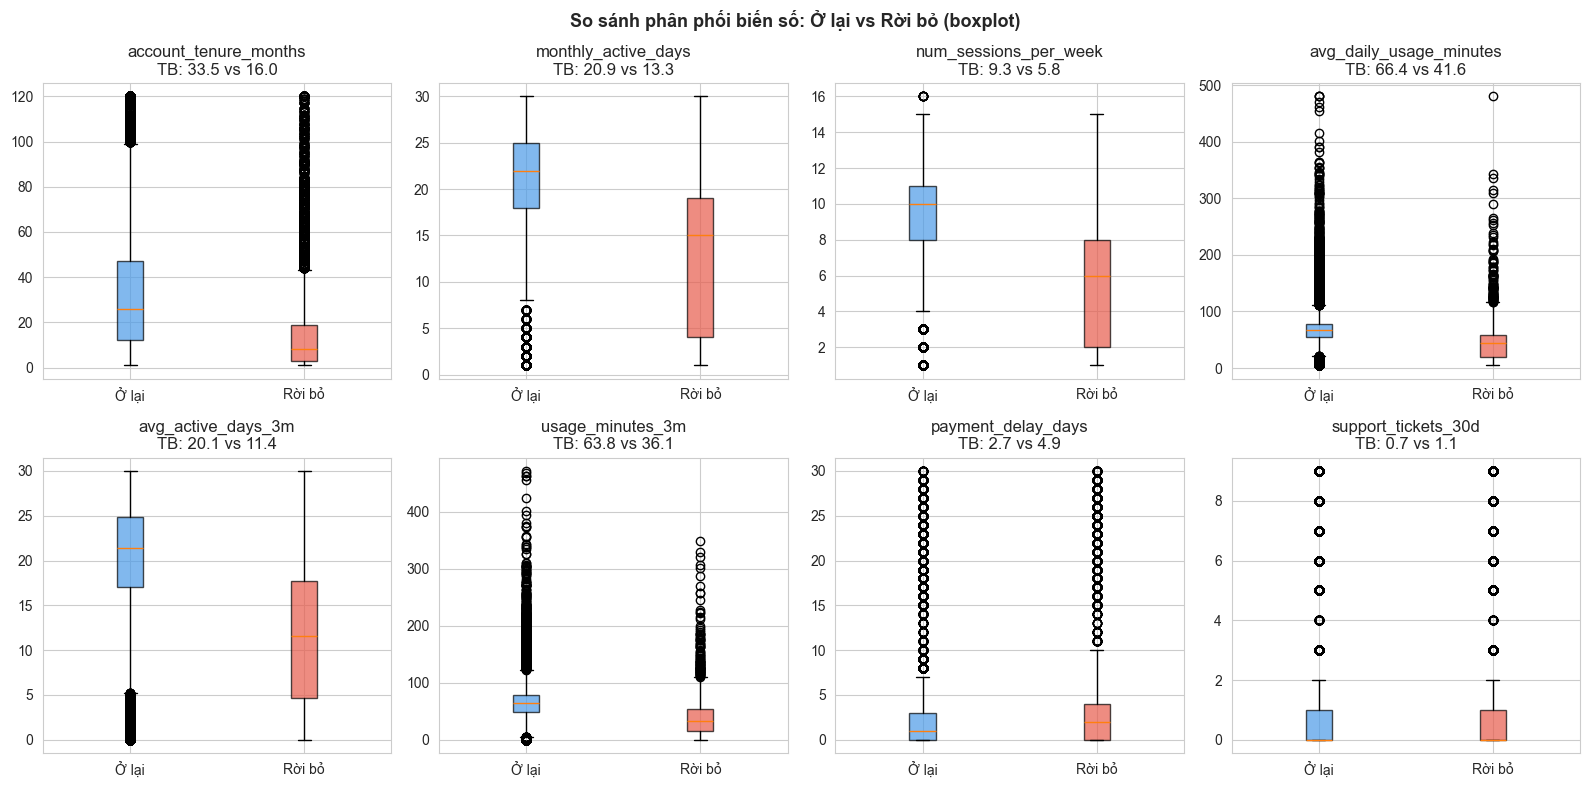

In [12]:
key_cols = [
    'account_tenure_months', 'monthly_active_days',
    'num_sessions_per_week', 'avg_daily_usage_minutes',
    'avg_active_days_3m', 'usage_minutes_3m',
    'payment_delay_days', 'support_tickets_30d'
]

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(key_cols):
    d0 = df[df['churn_target'] == 0][col]
    d1 = df[df['churn_target'] == 1][col]
    bp = axes[i].boxplot([d0, d1], patch_artist=True, labels=['Ở lại', 'Rời bỏ'])
    bp['boxes'][0].set_facecolor('#4C9BE8')
    bp['boxes'][1].set_facecolor('#E85C4C')
    for box in bp['boxes']:
        box.set_alpha(0.7)
    m0 = round(d0.mean(), 1)
    m1 = round(d1.mean(), 1)
    axes[i].set_title(col + '\nTB: ' + str(m0) + ' vs ' + str(m1))

plt.suptitle('So sánh phân phối biến số: Ở lại vs Rời bỏ (boxplot)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('data/05_boxplot_so_sanh.png', bbox_inches='tight')
plt.show()

**Nhận xét:**
- **monthly_active_days**: nhận biết rõ nhất. Nhóm rời bỏ TB chỉ 13.3 ngày, nhóm ở lại 21.0 ngày — khách ít dùng app rõ ràng là dấu hiệu sẽ rời bỏ.
- **num_sessions_per_week**: nhóm rời bỏ mở app ít hơn hẳn (TB 6.1 vs 9.7 phiên/tuần).
- **avg_daily_usage_minutes**: nhóm rời bỏ dùng ít hơn (41.6 vs 66.4 phút/ngày).
- **avg_active_days_3m**: nhóm rời bỏ ít hoạt động hơn trong 3 tháng gần nhất.
- **payment_delay_days**: nhóm rời bỏ trễ thanh toán nhiều hơn (4.9 vs 2.7 ngày).
- **account_tenure_months**: nhóm rời bỏ sử dụng app ít lâu hơn (16 vs 33.6 tháng).

### 3.3 Tỷ lệ churn theo biến danh mục

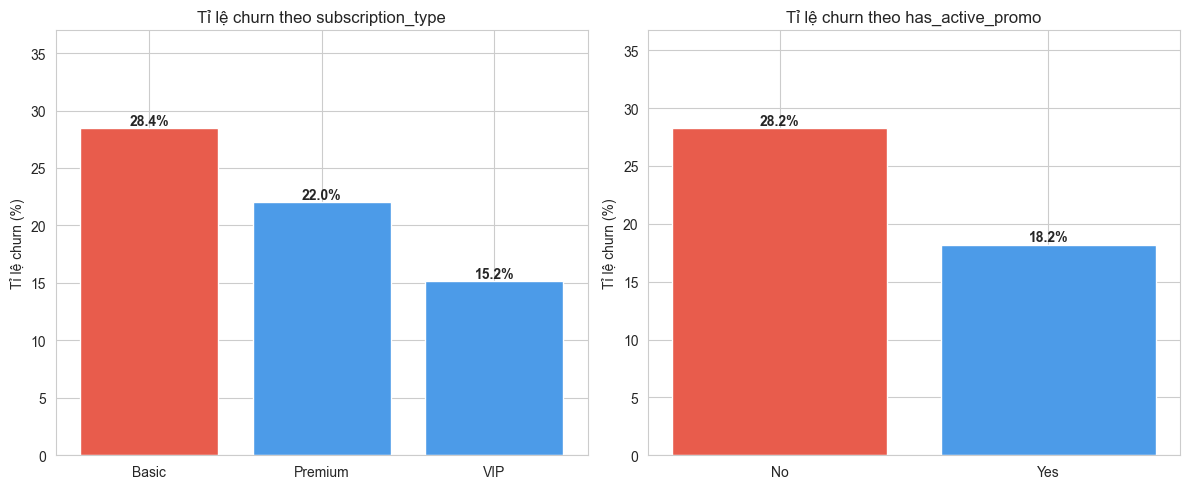

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for idx, col in enumerate(['subscription_type', 'has_active_promo']):
    churn_rate = df.groupby(col)['churn_target'].mean() * 100
    churn_rate = churn_rate.sort_values(ascending=False)
    colors_bar = ['#E85C4C' if v == churn_rate.max() else '#4C9BE8' for v in churn_rate.values]
    bars = axes[idx].bar(churn_rate.index, churn_rate.values, color=colors_bar)
    axes[idx].set_title('Tỉ lệ churn theo ' + col)
    axes[idx].set_ylabel('Tỉ lệ churn (%)')
    axes[idx].set_ylim(0, churn_rate.max() * 1.3)
    for bar, val in zip(bars, churn_rate.values):
        axes[idx].text(bar.get_x() + bar.get_width() / 2,
                       bar.get_height() + 0.3, str(round(val, 1)) + '%',
                       ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('data/06_churn_rate_danh_muc.png', bbox_inches='tight')
plt.show()

**Nhận xét:**
- Gói **Basic** có tỉ lệ churn cao nhất (28.4%), tiếp đến **Premium** (22.0%) và **VIP** (15.2%). Chênh lệch giữa Basic và VIP khá lớn (13.2%) — khách gói cao cấp cam kết hơn, đã đầu tư nhiều vào dịch vụ nên ít có ý định rời bỏ.
- Khách **KHÔNG có khuyến mãi** churn nhiều hơn rõ ràng (28.2% vs 18.2%). Khuyến mãi có tác dụng giữ chân rất rõ — Công ty TAD cần duy trì chính sách khuyến mãi, đặc biệt với nhóm khách có nguy cơ churn cao.

### 3.4 Ma trận tương quan toàn bộ

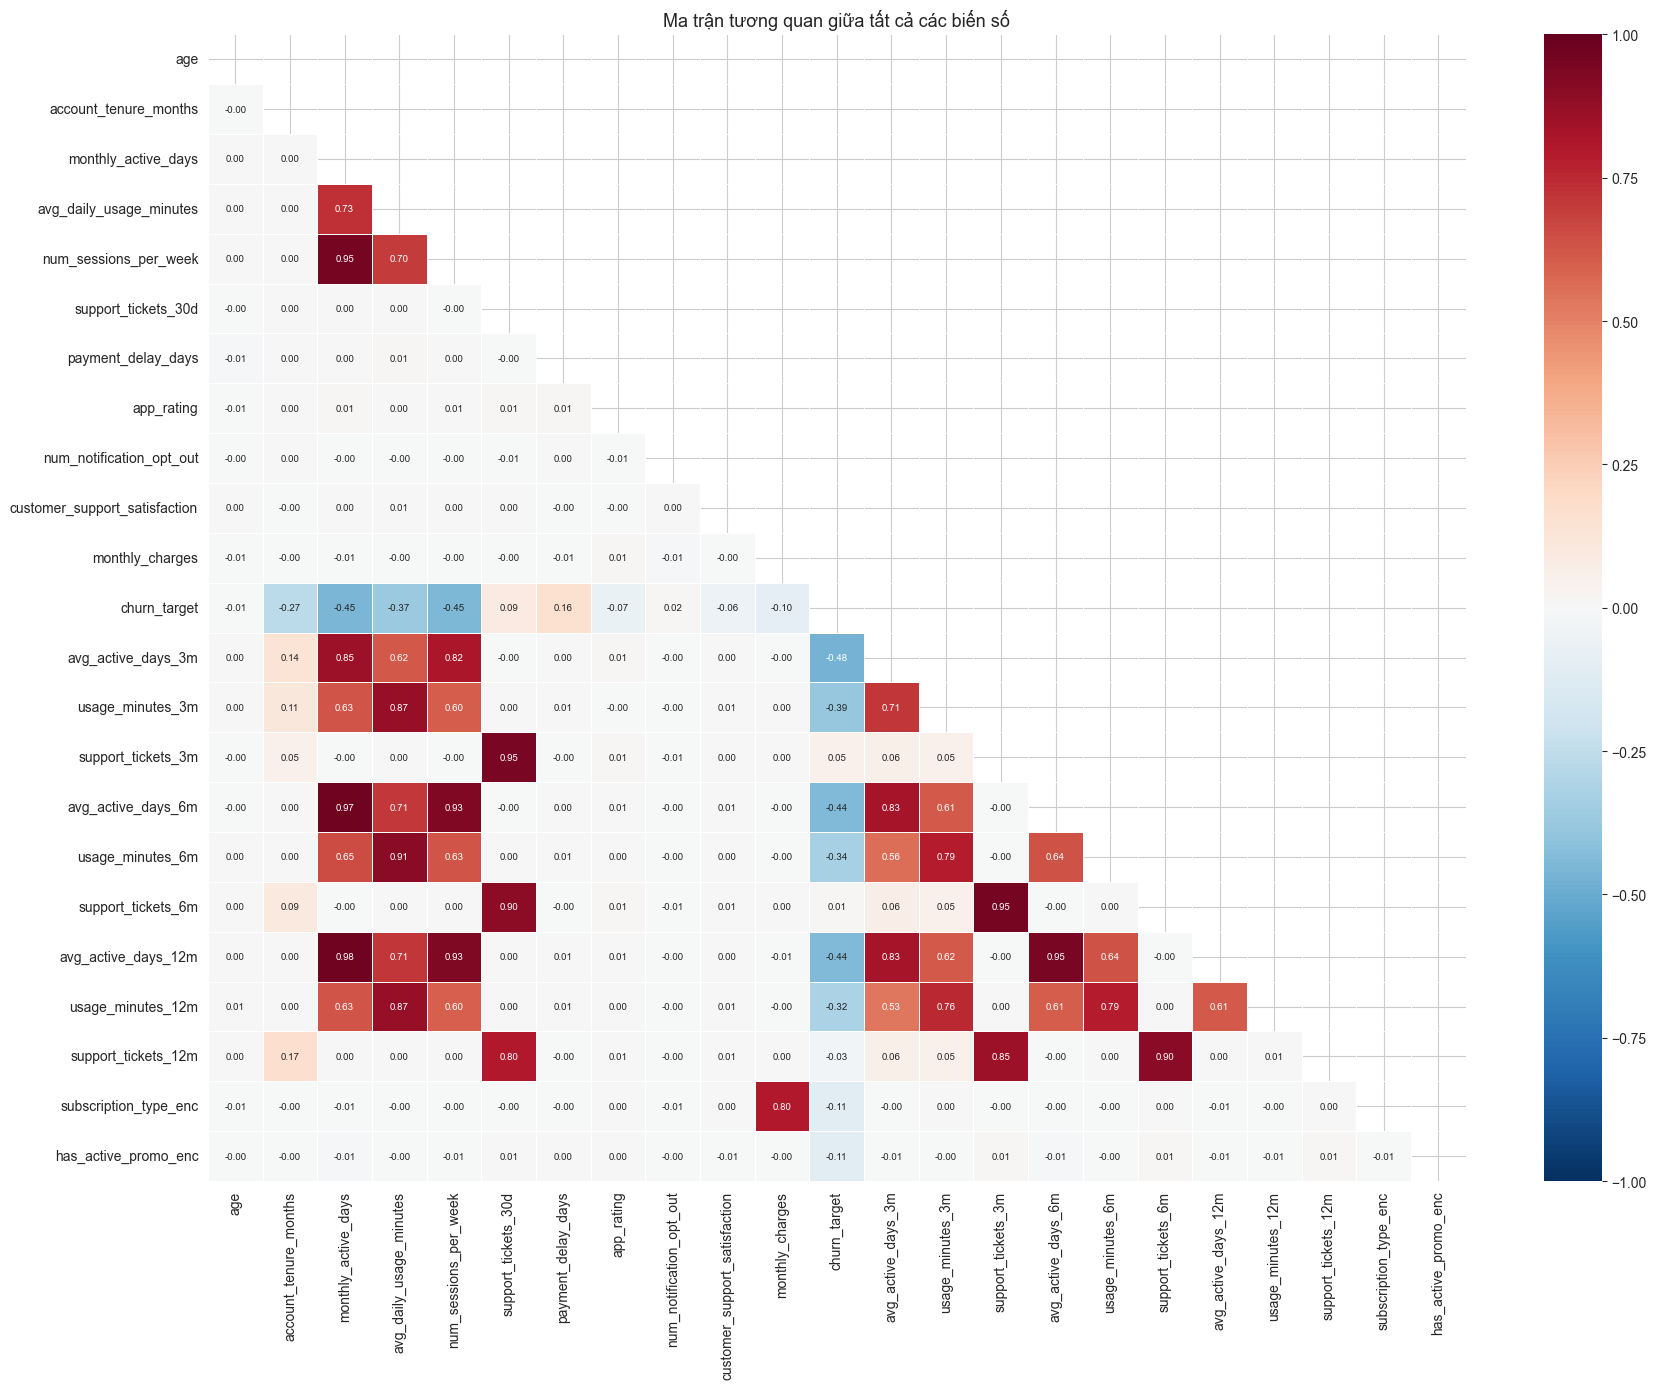

In [14]:
num_df = df_enc.drop(columns=['customer_id', 'subscription_type', 'has_active_promo'])

plt.figure(figsize=(18, 14))
corr_matrix = num_df.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            linewidths=0.4, annot_kws={'size': 7})
plt.title('Ma trận tương quan giữa tất cả các biến số', fontsize=13)
plt.tight_layout()
plt.savefig('data/07_ma_tran_tuong_quan.png', bbox_inches='tight')
plt.show()

**Nhận xét:**
- Nhóm **avg_active_days_3m / 6m / 12m** tương quan rất cao với nhau (> 0.90).
- Tương tự với nhóm **usage_minutes** và **support_tickets** theo timeframe.
- **monthly_active_days**, **num_sessions_per_week**, **avg_daily_usage_minutes** cũng tương quan cao với nhóm avg_active_days (vì cùng đo mức độ sử dụng app).
- Hiện tượng này gọi là **đa cộng tuyến** (multicollinearity). Giai đoạn 3 sẽ xử lý bằng bước Feature Selection (loại biến tương quan > 0.9).